Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\boxplot_grid_all_topics_3D.png


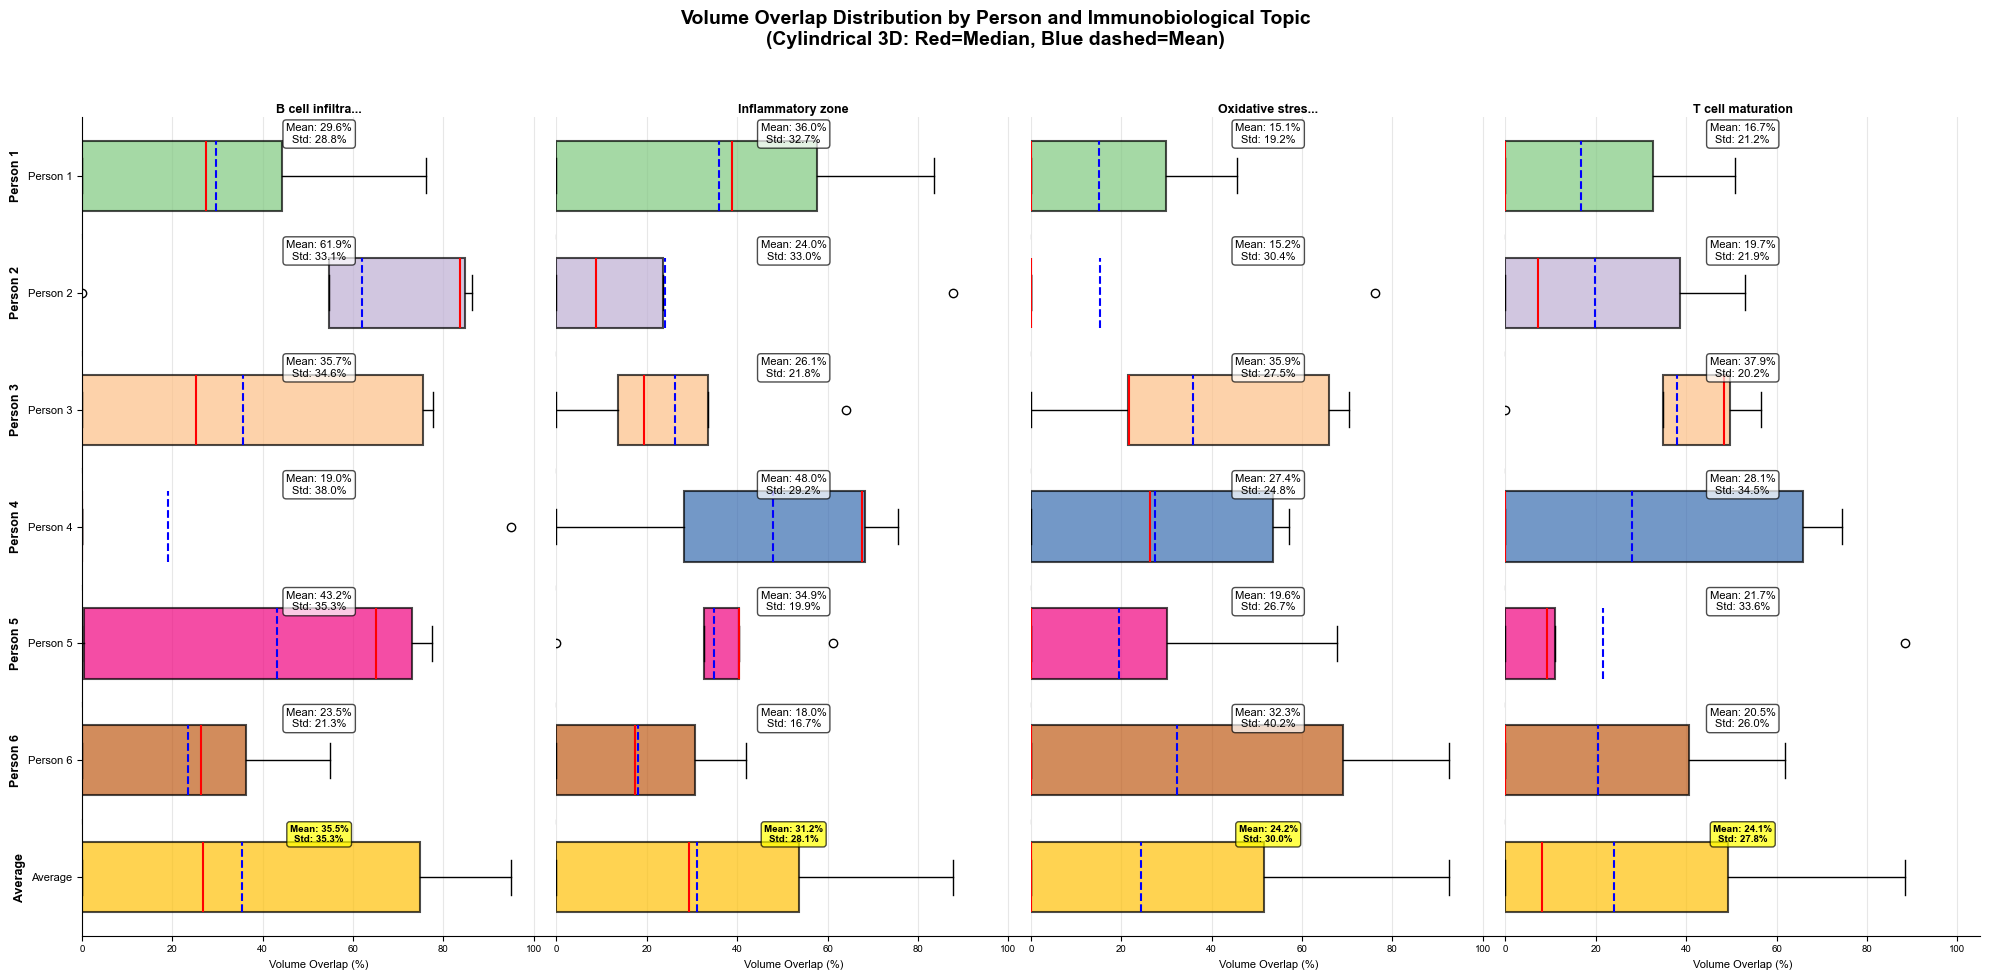

Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\heatmap_volume_overlap_3D.png


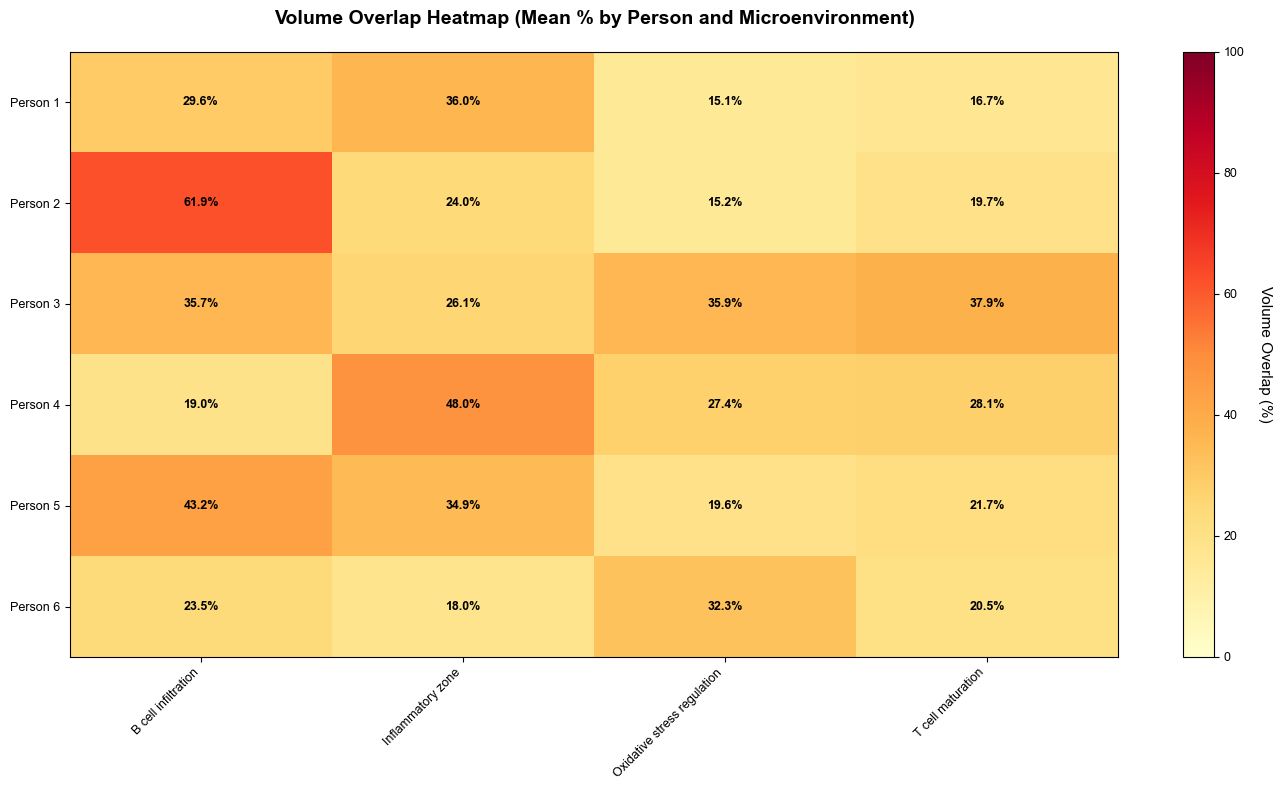

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math
import warnings
warnings.filterwarnings('ignore')

base_dir = Path(r"D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth")
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

cylinder_radius, cylinder_height = 400, 100
z_tolerance = 50

def circle_overlap(c1, c2, r):
    d = math.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)
    if d >= 2*r: return 0.0
    if d == 0: return 100.0
    try:
        area = 2*r**2*math.acos(d/(2*r)) - (d/2)*math.sqrt(4*r**2-d**2)
        return min(100.0, (area/(math.pi*r**2))*100)
    except: return 100.0 if d < 2*r else 0.0

def z_overlap(z1, z2, h, z_tol):
    dz = abs(z1 - z2)
    if dz <= z_tol:
        return 100.0
    excess_diff = dz - z_tol
    overlap_percent = max(0.0, 100.0 - (excess_diff / h) * 100)
    return overlap_percent

def volume_overlap(c1, z1, c2, z2, r, h, z_tol):
    xy_overlap = circle_overlap(c1, c2, r) / 100.0
    z_overlap_pct = z_overlap(z1, z2, h, z_tol) / 100.0
    return min(100.0, xy_overlap * z_overlap_pct * 100.0)

def calc_overlaps(gat_data, person_data, r, h, z_tol):
    if len(gat_data) == 0 or len(person_data) == 0: return []
    gat = gat_data[['x', 'y', 'z']].values
    person = person_data[['x', 'y', 'z']].values
    rows, cols = linear_sum_assignment(cdist(gat, person))
    return [volume_overlap((gat[i][0], gat[i][1]), gat[i][2], (person[j][0], person[j][1]), person[j][2], r, h, z_tol)
            for i, j in zip(rows, cols)]

# Process each CSV file
results = {}
all_overlaps = {f'Person {i}': [] for i in range(1, 7)}

for csv_filename in csv_files:
    csv_path = base_dir / csv_filename
    if not csv_path.exists():
        continue
    
    df = pd.read_csv(csv_path)
    sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
    
    gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
    gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
    
    results[sheet_name] = {}
    
    for person_num in range(1, 7):
        person_name = f'Person {person_num}'
        person_data = df[df.iloc[:, 0] == person_name].copy()
        person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        if len(person_data) == 0:
            continue
        
        overlaps = calc_overlaps(gat_data, person_data, cylinder_radius, cylinder_height, z_tolerance)
        
        if len(overlaps) > 0:
            results[sheet_name][person_name] = {
                'overlaps': overlaps,
                'mean': np.mean(overlaps),
                'std': np.std(overlaps),
                'min': np.min(overlaps),
                'max': np.max(overlaps)
            }
            all_overlaps[person_name].extend(overlaps)


person_names = [f'Person {i}' for i in range(1, 7)]
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#386cb0', '#f0027f', '#bf5b17']
topics_list = list(results.keys()) if len(results) > 0 else []

fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(7, 4, hspace=0.0, wspace=0.0)

for col_idx, sheet_name in enumerate(topics_list):
    all_topic_overlaps = []
    
    for row_idx, person_name in enumerate(person_names):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        
        if person_name in results[sheet_name]:
            overlaps = results[sheet_name][person_name]['overlaps']
            if len(overlaps) > 0:
                all_topic_overlaps.extend(overlaps)
                bp = ax.boxplot([overlaps], tick_labels=[person_name], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
                bp['boxes'][0].set_facecolor(person_colors[row_idx])
                bp['boxes'][0].set_alpha(0.7)
                bp['boxes'][0].set_edgecolor('black')
                bp['boxes'][0].set_linewidth(1.5)
                
                stats = results[sheet_name][person_name]
                stats_text = f"Mean: {stats['mean']:.1f}%\nStd: {stats['std']:.1f}%"
                ax.text(0.5, 0.95, stats_text, transform=ax.transAxes,
                       ha='center', va='top', fontsize=8,
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
            else:
                bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
                bp['boxes'][0].set_facecolor('lightgray')
                bp['boxes'][0].set_alpha(0.3)
        else:
            bp = ax.boxplot([[]], tick_labels=[person_name], patch_artist=True, vert=False, widths=0.6)
            bp['boxes'][0].set_facecolor('lightgray')
            bp['boxes'][0].set_alpha(0.3)
        
        ax.set_xlim(0, 105)
        ax.grid(True, alpha=0.3, axis='x')
        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelsize=7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if row_idx < 6:
            ax.spines['bottom'].set_visible(False)
        if col_idx > 0:
            ax.spines['left'].set_visible(False)
        
        if col_idx == 0:
            ax.set_ylabel(person_name, fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel('')
            ax.set_yticks([])
        
        if row_idx == 6:
            ax.set_xlabel('Volume Overlap (%)', fontsize=8)
        else:
            ax.set_xticklabels([])
        
        if row_idx == 0:
            short_name = sheet_name.replace('_', ' ').replace('-', ' ')
            if len(short_name) > 18:
                short_name = short_name[:15] + '...'
            ax.set_title(short_name, fontsize=9, fontweight='bold', pad=3)
    
    ax_avg = fig.add_subplot(gs[6, col_idx])
    if len(all_topic_overlaps) > 0:
        bp_avg = ax_avg.boxplot([all_topic_overlaps], tick_labels=['Average'], patch_artist=True,
                               vert=False, showmeans=True, meanline=True,
                               boxprops=dict(linewidth=1.5),
                               medianprops=dict(linewidth=1.5, color='red'),
                               meanprops=dict(linewidth=1.5, linestyle='--', color='blue'),
                               whiskerprops=dict(linewidth=1), capprops=dict(linewidth=1), widths=0.6)
        bp_avg['boxes'][0].set_facecolor('#FFC107')
        bp_avg['boxes'][0].set_alpha(0.7)
        bp_avg['boxes'][0].set_edgecolor('black')
        bp_avg['boxes'][0].set_linewidth(1.5)
        
        stats_text = f"Mean: {np.mean(all_topic_overlaps):.1f}%\nStd: {np.std(all_topic_overlaps):.1f}%"
        ax_avg.text(0.5, 0.95, stats_text, transform=ax_avg.transAxes,
                   ha='center', va='top', fontsize=7, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    else:
        bp_avg = ax_avg.boxplot([[]], tick_labels=['Average'], patch_artist=True, vert=False, widths=0.6)
        bp_avg['boxes'][0].set_facecolor('lightgray')
        bp_avg['boxes'][0].set_alpha(0.3)
    
    ax_avg.set_xlim(0, 105)
    ax_avg.grid(True, alpha=0.3, axis='x')
    ax_avg.tick_params(axis='y', labelsize=8)
    ax_avg.tick_params(axis='x', labelsize=7)
    ax_avg.set_xlabel('Volume Overlap (%)', fontsize=8)
    ax_avg.spines['top'].set_visible(False)
    ax_avg.spines['right'].set_visible(False)
    if col_idx > 0:
        ax_avg.spines['left'].set_visible(False)
    
    if col_idx == 0:
        ax_avg.set_ylabel('Average', fontsize=9, fontweight='bold')
    else:
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])

fig.suptitle('Volume Overlap Distribution by Person and Immunobiological Topic\n(Cylindrical 3D: Red=Median, Blue dashed=Mean)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.02, 1, 0.97])
output_path = base_dir / 'boxplot_grid_all_topics_3D.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

# Create heatmap
fig2, ax2 = plt.subplots(figsize=(14, 8))
heatmap_data = []
heatmap_rows = []
heatmap_cols = topics_list

for person_name in person_names:
    row_data = []
    for sheet_name in topics_list:
        if person_name in results[sheet_name] and len(results[sheet_name][person_name]['overlaps']) > 0:
            row_data.append(results[sheet_name][person_name]['mean'])
        else:
            row_data.append(np.nan)
    if any(not np.isnan(x) for x in row_data):
        heatmap_data.append(row_data)
        heatmap_rows.append(person_name)

if len(heatmap_data) > 0:
    heatmap_array = np.array(heatmap_data)
    im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    
    ax2.set_xticks(np.arange(len(heatmap_cols)))
    ax2.set_yticks(np.arange(len(heatmap_rows)))
    ax2.set_xticklabels([name.replace('_', ' ').replace('-', ' ') for name in heatmap_cols], rotation=45, ha='right')
    ax2.set_yticklabels(heatmap_rows)
    
    for i in range(len(heatmap_rows)):
        for j in range(len(heatmap_cols)):
            if not np.isnan(heatmap_array[i, j]):
                text = ax2.text(j, i, f'{heatmap_array[i, j]:.1f}%',
                              ha="center", va="center", color="black", fontsize=9, fontweight='bold')
    
    ax2.set_title('Volume Overlap Heatmap (Mean % by Person and Microenvironment)', fontsize=14, fontweight='bold', pad=20)
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Volume Overlap (%)', rotation=270, labelpad=20)
    
    plt.tight_layout()
    heatmap_path = base_dir / 'heatmap_volume_overlap_3D.png'
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {heatmap_path}")
    plt.show()


heatmap calculation for overlap in volumetric

Boxplot for voulmetric response

Adding median to existing results if missing...
✓ Median values added.
✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\errorbar_grid_all_topics_volumetric.png


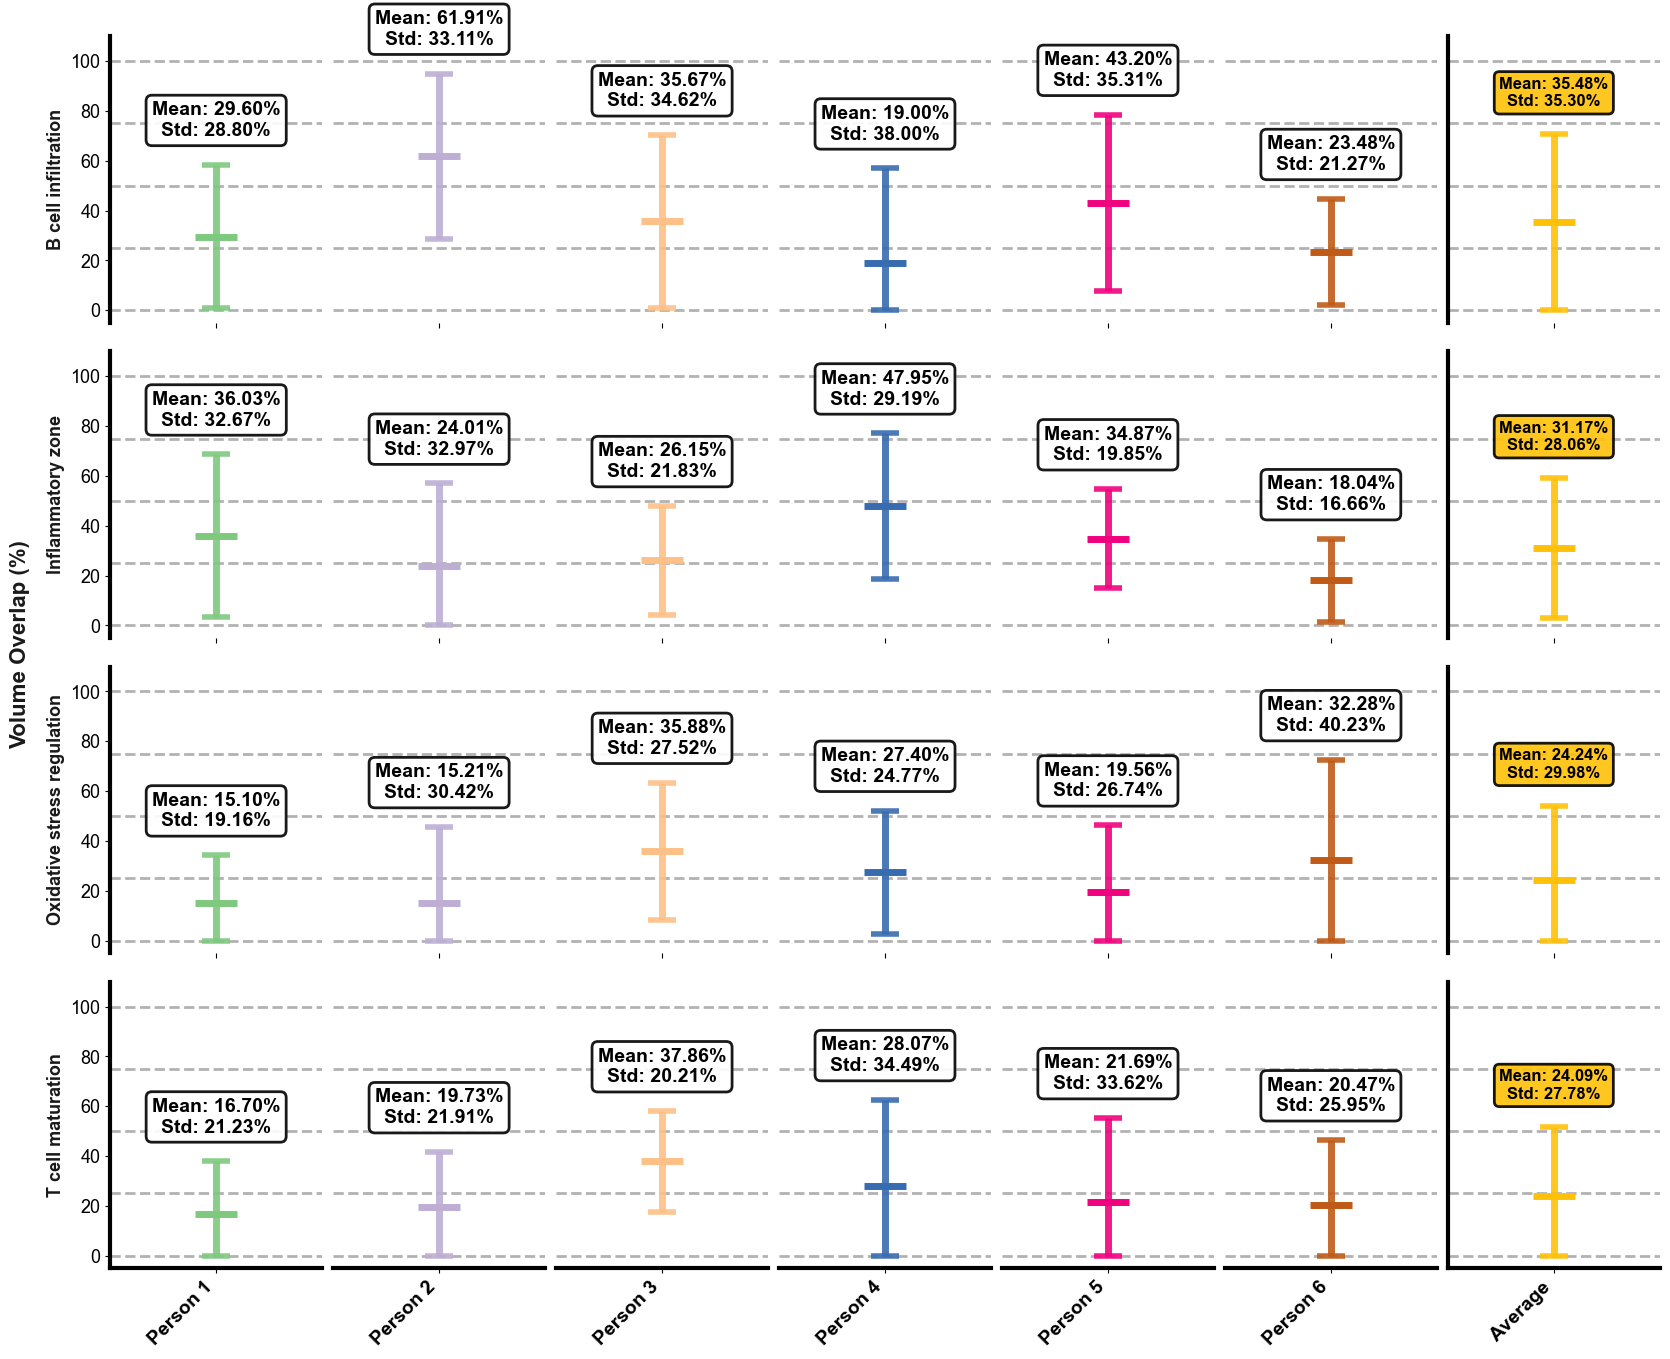

✓ Saved: D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth\heatmap_volume_overlap_median_errorbar.png


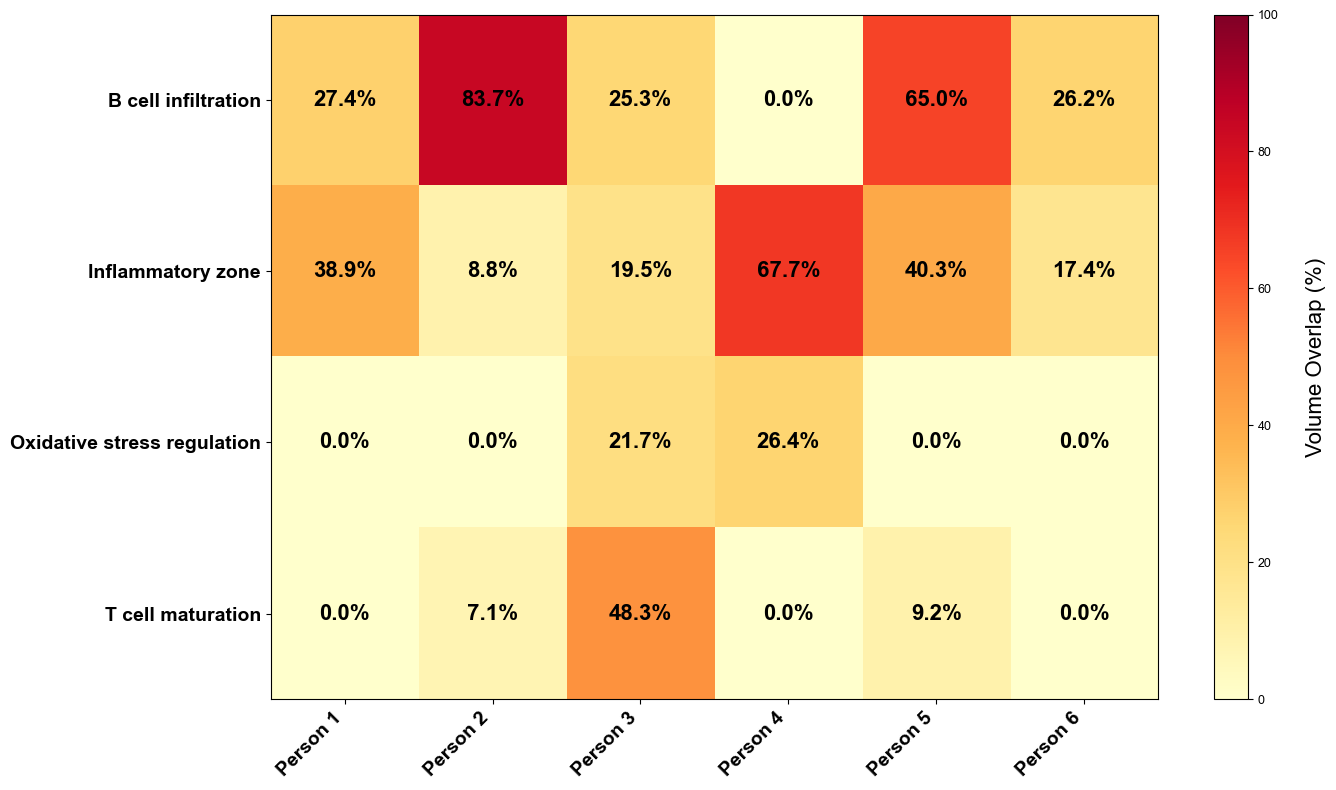

In [3]:
"""
Inter-Rater Error Bar Chart for Volumetric Data
Creates error bar chart similar to Euclidean distance chart
Grid: 4 rows (topics/microenvironments) x 7 columns (6 Persons + Average)
Each cell shows vertical error bar with Mean ± Std
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import math
import warnings
import os
warnings.filterwarnings('ignore')

# Configuration
BASE_DIR = r'D:\VIS2025\BIoVisChallenges\SSGAT\Groundtruth'
base_dir = Path(BASE_DIR)
csv_files = [
    'roi_coordinates_B-cell_infiltration.csv',
    'roi_coordinates_Inflammatory_zone.csv',
    'roi_coordinates_Oxidative_stress_regulation.csv',
    'roi_coordinates_T-cell_maturation.csv'
]

cylinder_radius, cylinder_height = 400, 100
z_tolerance = 50

def circle_overlap(c1, c2, r):
    d = math.sqrt((c2[0]-c1[0])**2 + (c2[1]-c1[1])**2)
    if d >= 2*r: return 0.0
    if d == 0: return 100.0
    try:
        area = 2*r**2*math.acos(d/(2*r)) - (d/2)*math.sqrt(4*r**2-d**2)
        return min(100.0, (area/(math.pi*r**2))*100)
    except: return 100.0 if d < 2*r else 0.0

def z_overlap(z1, z2, h, z_tol):
    dz = abs(z1 - z2)
    if dz <= z_tol:
        return 100.0
    excess_diff = dz - z_tol
    overlap_percent = max(0.0, 100.0 - (excess_diff / h) * 100)
    return overlap_percent

def volume_overlap(c1, z1, c2, z2, r, h, z_tol):
    xy_overlap = circle_overlap(c1, c2, r) / 100.0
    z_overlap_pct = z_overlap(z1, z2, h, z_tol) / 100.0
    return min(100.0, xy_overlap * z_overlap_pct * 100.0)

def calc_overlaps(gat_data, person_data, r, h, z_tol):
    if len(gat_data) == 0 or len(person_data) == 0: return []
    gat = gat_data[['x', 'y', 'z']].values
    person = person_data[['x', 'y', 'z']].values
    rows, cols = linear_sum_assignment(cdist(gat, person))
    return [volume_overlap((gat[i][0], gat[i][1]), gat[i][2], (person[j][0], person[j][1]), person[j][2], r, h, z_tol)
            for i, j in zip(rows, cols)]

# Process each CSV file (if results not already available)
# Also add median to existing results if missing
if 'results' not in globals() or len(globals().get('results', {})) == 0:
    print("Processing volumetric data...")
    results = {}
    all_overlaps = {f'Person {i}': [] for i in range(1, 7)}
    
    for csv_filename in csv_files:
        csv_path = base_dir / csv_filename
        if not csv_path.exists():
            continue
        
        df = pd.read_csv(csv_path)
        sheet_name = csv_filename.replace('roi_coordinates_', '').replace('.csv', '')
        
        gat_data = df[df.iloc[:, 0] == 'GAT'].copy()
        gat_data = gat_data.sort_values(by='ROI_ID').reset_index(drop=True)
        
        results[sheet_name] = {}
        
        for person_num in range(1, 7):
            person_name = f'Person {person_num}'
            person_data = df[df.iloc[:, 0] == person_name].copy()
            person_data = person_data.sort_values(by='ROI_ID').reset_index(drop=True)
            
            if len(person_data) == 0:
                continue
            
            overlaps = calc_overlaps(gat_data, person_data, cylinder_radius, cylinder_height, z_tolerance)
            
            if len(overlaps) > 0:
                results[sheet_name][person_name] = {
                    'overlaps': overlaps,
                    'mean': np.mean(overlaps),
                    'median': np.median(overlaps),
                    'std': np.std(overlaps),
                    'min': np.min(overlaps),
                    'max': np.max(overlaps)
                }
                all_overlaps[person_name].extend(overlaps)
    print("✓ Data processing complete.")
else:
    # Add median to existing results if missing (for backwards compatibility)
    print("Adding median to existing results if missing...")
    for sheet_name in results.keys():
        for person_name in results[sheet_name].keys():
            stats = results[sheet_name][person_name]
            if 'median' not in stats and 'overlaps' in stats:
                stats['median'] = np.median(stats['overlaps'])
    print("✓ Median values added.")

# Get topics and person names
person_names = [f'Person {i}' for i in range(1, 7)]
person_colors = ['#7fc97f', '#beaed4', '#fdc086', '#386cb0', '#f0027f', '#bf5b17']
topics_list = list(results.keys()) if len(results) > 0 else []

# Set better font settings
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.titlesize'] = 14

if len(topics_list) > 0:
    # Grid: rows = topics (microenvironments), columns = persons + average
    num_topics = len(topics_list)
    num_cols = len(person_names) + 1  # +1 for average column
    fig = plt.figure(figsize=(20, 4 * num_topics))
    gs = fig.add_gridspec(num_topics, num_cols, hspace=0.1, wspace=0.05)

    for row_idx, sheet_name in enumerate(topics_list):
        all_topic_overlaps = []
        
        # Plot each person in columns
        for col_idx, person_name in enumerate(person_names):
            ax = fig.add_subplot(gs[row_idx, col_idx])
            
            if person_name in results[sheet_name]:
                overlaps = results[sheet_name][person_name]['overlaps']
                if len(overlaps) > 0:
                    all_topic_overlaps.extend(overlaps)
                    stats = results[sheet_name][person_name]
                    # Use mean for error bar plot
                    mean_val = stats['mean']
                    std_val = stats['std']
                    
                    # Create error bar plot (vertical, similar to Euclidean plot)
                    x_pos = 0.5
                    color = person_colors[col_idx]
                    
                    # Error bar (vertical line with caps) - thicker lines
                    # Limit error bar to minimum 0 (mean - std cannot be negative)
                    # Also limit upper error bar to maximum 100% (volume overlap cannot exceed 100%)
                    yerr_lower = min(std_val, mean_val)  # Ensure error bar doesn't go below 0
                    yerr_upper = min(std_val, 100 - mean_val)  # Ensure error bar doesn't go above 100%
                    ax.errorbar(x_pos, mean_val, yerr=[[yerr_lower], [yerr_upper]], fmt='none', color=color, 
                               capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
                    # Point estimate (horizontal line marker) - thicker
                    ax.plot(x_pos, mean_val, marker='_', color=color, markersize=30, 
                           markeredgewidth=5, alpha=1.0, linewidth=6)
                    
                    stats_text = f"Mean: {mean_val:.2f}%\nStd: {std_val:.2f}%"
                    # Position text 10 units above the maximum error bar (but not more than 110)
                    text_y_pos = min(mean_val + yerr_upper + 10, 110)
                    ax.text(x_pos, text_y_pos, stats_text,
                           ha='center', va='bottom', fontsize=14, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='black', linewidth=2))
                else:
                    # Empty plot
                    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                           ha='center', va='center', fontsize=14, color='gray')
            else:
                # Empty plot
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                       ha='center', va='center', fontsize=14, color='gray')
            
            # Set ylim to accommodate text boxes - limit to 110% max (since values cannot exceed 100%)
            ax.set_ylim(-5, 110)
            ax.set_xlim(0, 1)
            ax.set_xticks([0.5])
            ax.set_xticklabels([person_name], rotation=45, ha='right', fontsize=14, fontweight='bold')
            
            # For first column, only show specific dash lines (0, 25, 50, 75, 100)
            # For other columns, show grid
            if col_idx == 0:
                # Add horizontal dash lines at 0, 25, 50, 75, 100 only
                for y_val in [0, 25, 50, 75, 100]:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            else:
                ax.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
                # Add horizontal dash lines at 0, 25, 50, 75, 100
                for y_val in [0, 25, 50, 75, 100]:
                    ax.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
            
            ax.tick_params(axis='x', labelsize=14, colors='black')
            ax.tick_params(axis='y', labelsize=13, colors='black')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['left'].set_linewidth(3)
            ax.spines['bottom'].set_linewidth(3)
            if row_idx < num_topics - 1:
                ax.spines['bottom'].set_visible(False)
            if col_idx > 0:
                ax.spines['left'].set_visible(False)
            
            if col_idx == 0:
                # Set microenvironment name as ylabel
                microenv_name = sheet_name.replace('_', ' ').replace('-', ' ')
                ax.set_ylabel(microenv_name, fontsize=13, fontweight='bold', color='#1a1a1a')
            else:
                ax.set_ylabel('')
                ax.set_yticks([])
            
            if row_idx < num_topics - 1:
                ax.set_xticklabels([])
        
        # Plot average in last column (using mean)
        ax_avg = fig.add_subplot(gs[row_idx, num_cols - 1])
        if len(all_topic_overlaps) > 0:
            mean_avg = np.mean(all_topic_overlaps)
            std_avg = np.std(all_topic_overlaps)
            x_pos_avg = 0.5
            
            # Error bar for average (vertical) - thicker lines
            # Limit error bar to minimum 0 (mean - std cannot be negative)
            # Also limit upper error bar to maximum 100% (volume overlap cannot exceed 100%)
            yerr_lower_avg = min(std_avg, mean_avg)  # Ensure error bar doesn't go below 0
            yerr_upper_avg = min(std_avg, 100 - mean_avg)  # Ensure error bar doesn't go above 100%
            ax_avg.errorbar(x_pos_avg, mean_avg, yerr=[[yerr_lower_avg], [yerr_upper_avg]], fmt='none', color='#FFC107', 
                           capsize=10, capthick=4, linewidth=5, alpha=0.9, elinewidth=5)
            ax_avg.plot(x_pos_avg, mean_avg, marker='_', color='#FFC107', markersize=30, 
                       markeredgewidth=5, alpha=1.0, linewidth=6)
            
            stats_text = f"Mean: {mean_avg:.2f}%\nStd: {std_avg:.2f}%"
            # Position text 10 units above the maximum error bar (but not more than 110)
            text_y_pos_avg = min(mean_avg + yerr_upper_avg + 10, 110)
            ax_avg.text(x_pos_avg, text_y_pos_avg, stats_text,
                       ha='center', va='bottom', fontsize=12, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='#FFC107', alpha=0.9, edgecolor='black', linewidth=2))
        else:
            ax_avg.text(0.5, 0.5, 'No data', transform=ax_avg.transAxes,
                       ha='center', va='center', fontsize=12, color='gray')
        
        # Set ylim to accommodate text boxes - limit to 110% max (since values cannot exceed 100%)
        ax_avg.set_ylim(-5, 110)
        ax_avg.set_xlim(0, 1)
        ax_avg.set_xticks([0.5])
        ax_avg.set_xticklabels(['Average'], rotation=45, ha='right', fontsize=12, fontweight='bold')
        ax_avg.grid(True, alpha=0.4, axis='y', linestyle='--', linewidth=2)
        
        # Add horizontal dash lines at 0, 25, 50, 75, 100
        for y_val in [0, 25, 50, 75, 100]:
            ax_avg.axhline(y=y_val, color='gray', linestyle='--', linewidth=2, alpha=0.6, zorder=0)
        
        ax_avg.tick_params(axis='x', labelsize=14, colors='black')
        ax_avg.tick_params(axis='y', labelsize=13, colors='black')
        if row_idx < num_topics - 1:
            ax_avg.set_xticklabels([])
        ax_avg.spines['top'].set_visible(False)
        ax_avg.spines['right'].set_visible(False)
        ax_avg.spines['left'].set_linewidth(3)
        ax_avg.spines['bottom'].set_linewidth(3)
        if row_idx < num_topics - 1:
            ax_avg.spines['bottom'].set_visible(False)
        ax_avg.set_ylabel('')
        ax_avg.set_yticks([])
    
    # Add "Volume Overlap (%)" label on the leftmost position for all rows
    fig.text(0.08, 0.5, 'Volume Overlap (%)', fontsize=16, fontweight='bold', 
             rotation=90, va='center', ha='center', color='#1a1a1a')

    # fig.suptitle('Volume Overlap by Microenvironment (Rows) and Person (Columns)-(Error bars show Mean ± Std)', 
                #  fontsize=20, fontweight='bold', y=0.95, color='#1a1a1a')
    plt.tight_layout(rect=[0.04, 0.02, 1, 0.97])
    output_path = base_dir / 'errorbar_grid_all_topics_volumetric.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()

    # Create heatmap for median
    # Person in x-direction (columns), Microenvironment in y-direction (rows) - like inter-rater
    fig2, ax2 = plt.subplots(figsize=(14, 8))
    heatmap_data = []
    heatmap_rows = []  # Microenvironments (y-axis)
    heatmap_cols = person_names  # Persons (x-axis)
    
    for sheet_name in topics_list:
        row_data = []
        for person_name in person_names:
            if person_name in results[sheet_name] and len(results[sheet_name][person_name]['overlaps']) > 0:
                stats = results[sheet_name][person_name]
                # Calculate median if not already present (for backwards compatibility)
                if 'median' not in stats:
                    stats['median'] = np.median(stats['overlaps'])
                row_data.append(stats['median'])
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
        heatmap_rows.append(sheet_name.replace('_', ' ').replace('-', ' '))
    
    if len(heatmap_data) > 0:
        heatmap_array = np.array(heatmap_data)
        im = ax2.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
        
        ax2.set_xticks(np.arange(len(heatmap_cols)))
        ax2.set_yticks(np.arange(len(heatmap_rows)))
        ax2.set_xticklabels(heatmap_cols, rotation=45, ha='right', fontsize=14, fontweight='bold')
        ax2.set_yticklabels(heatmap_rows, rotation=0,  fontsize=14 ,fontweight='bold')
        
        for i in range(len(heatmap_rows)):
            for j in range(len(heatmap_cols)):
                if not np.isnan(heatmap_array[i, j]):
                    text = ax2.text(j, i, f'{heatmap_array[i, j]:.1f}%',
                                  ha="center", va="center", color="black", fontsize=16, fontweight='bold')
        
        # ax2.set_title('Volume Overlap Heatmap (Median % by Person and Microenvironment)', fontsize=16, fontweight='bold', pad=20)
        cbar = plt.colorbar(im, ax=ax2)
        cbar.set_label('Volume Overlap (%)', labelpad=20, fontsize=16)
        
        plt.tight_layout()
        heatmap_path = base_dir / 'heatmap_volume_overlap_median_errorbar.png'
        plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {heatmap_path}")
        plt.show()
else:
    print("Error: No volumetric data found. Please ensure CSV files exist and contain data.")
